# KDE

In [2]:
import astropy.coordinates as coord 
from astropy.table import Table 
import astropy.units as u 
 
import numpy as np 
import matplotlib.pyplot as plt 
%matplotlib inline 
from scipy.stats import norm 
from scipy.special import logsumexp 
from scipy.optimize import minimize 
from sklearn.neighbors import KernelDensity 
from sklearn.model_selection import GridSearchCV

In [3]:
np.random.seed(42) 
x1 = np.random.normal(0.25, 0.1, size=200) 
x2 = np.random.normal(1., 0.5, size=1000) 
x = np.concatenate((x1, x2)) 
np.random.shuffle(x) # we'll rely on this later! 
 
def true_x_density(x): 
    return ((1/6)*norm.pdf(x, loc=0.25, scale=0.1) +  
            (5/6)*norm.pdf(x, loc=1., scale=0.5))

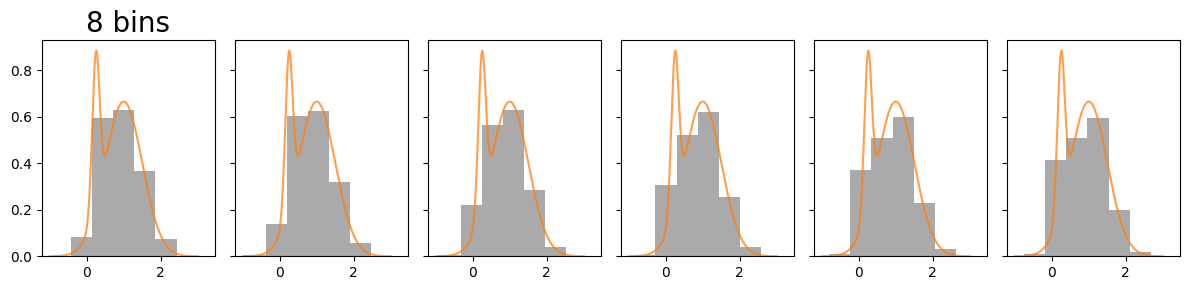

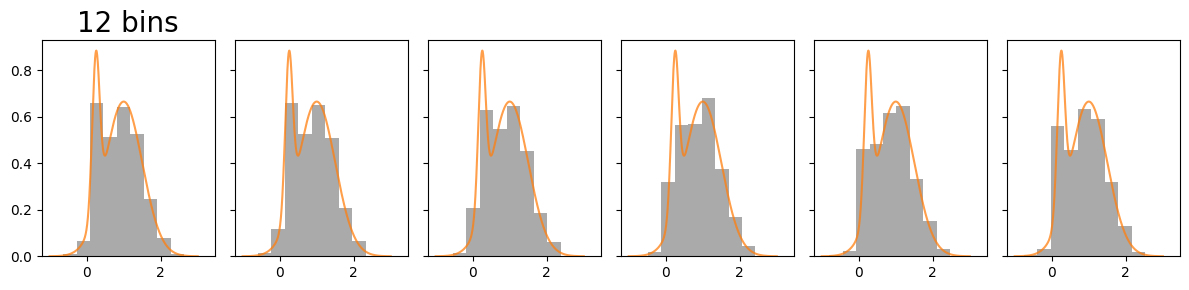

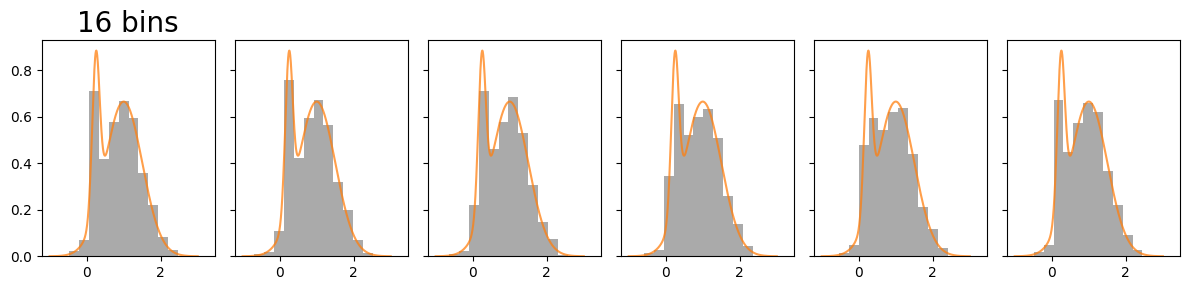

In [4]:
for n_bins in [8, 12, 16]: 
    bins = np.linspace(-1, 3, n_bins) 
 
    fig, axes = plt.subplots(1, 6, figsize=(12, 3),  
                             sharex=True, sharey=True) 
     
    x_grid = np.linspace(-1, 3, 1000) 
    for i, ax in enumerate(axes.flat): 
        ax.hist(x, bins=bins + i/20, density=True, color='#aaaaaa') 
        ax.plot(x_grid, true_x_density(x_grid), marker='',  
                alpha=0.75, zorder=10, color='tab:orange') 
     
    axes[0].set_title('{0} bins'.format(n_bins), fontsize=20) 
    fig.tight_layout()

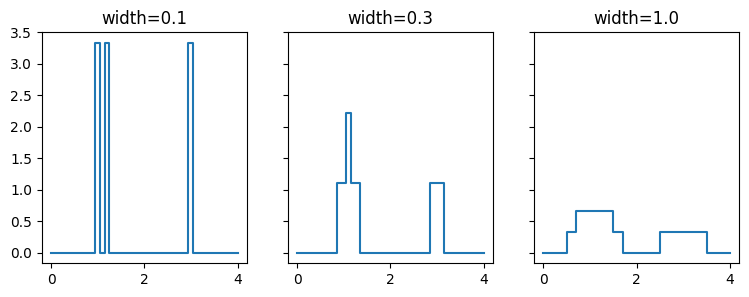

In [5]:
def point_centered_histogram(x, bin_width, data): 
    data = np.array(data) 
    x = np.array(x) 
    y = (data[None] - x[:, None]) / (bin_width/2.) 
    return np.sum(np.abs(y) < 1., axis=1) / (len(data) * bin_width)

x_grid = np.linspace(0, 4, 512) 
data = [1., 1.2, 3.] 
bin_widths = [0.1, 0.3, 1.] 
 
fig, axes = plt.subplots(1, 3, figsize=(9, 3), sharex=True, sharey=True) 
 
for i, ax in enumerate(axes.flat): 
    ax.plot(x_grid, point_centered_histogram(x_grid, bin_widths[i], data),  
            marker='', drawstyle='steps-mid') 
     
    ax.set_title('width={0:.1f}'.format(bin_widths[i]))

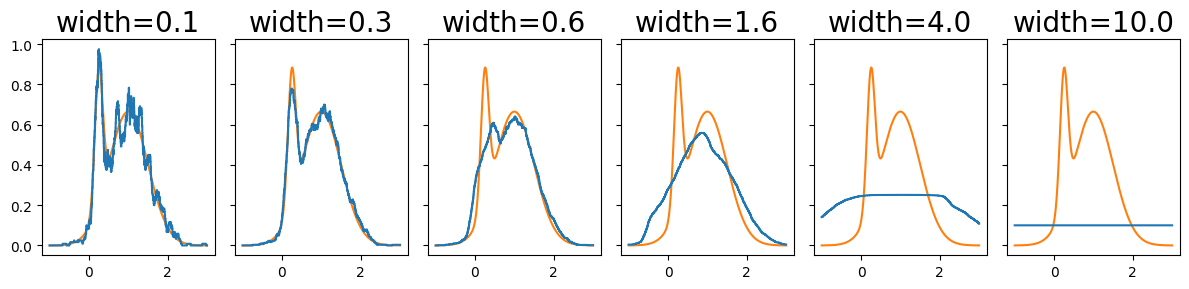

In [6]:
fig, axes = plt.subplots(1, 6, figsize=(12, 3),  
                         sharex=True, sharey=True) 
 
bin_widths = np.logspace(-1, 1, len(axes)) 
 
x_grid = np.linspace(-1, 3, 1024) 
for i, ax in enumerate(axes.flat): 
    ax.plot(x_grid, point_centered_histogram(x_grid, bin_widths[i], x),  
            marker='', drawstyle='steps-mid') 
     
    ax.plot(x_grid, true_x_density(x_grid),  
            zorder=-10, marker='') 
 
    ax.set_title('width={0:.1f}'.format(bin_widths[i]), fontsize=20) 
fig.tight_layout() 
 
# Show the figure 
plt.tight_layout()

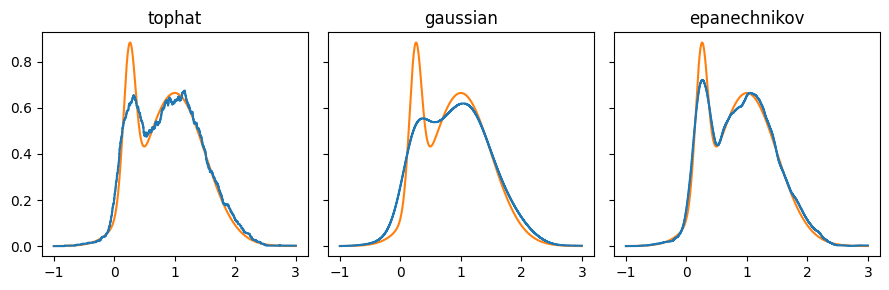

In [7]:
kde_tophat = KernelDensity(bandwidth=0.2, kernel='tophat') 
kde_gauss = KernelDensity(bandwidth=0.2, kernel='gaussian') 
kde_epan = KernelDensity(bandwidth=0.2, kernel='epanechnikov') 
kdes = [kde_tophat, kde_gauss, kde_epan] 
 
X = x.reshape(-1, 1) 
for kde in kdes: 
    kde.fit(X) 
 
fig, axes = plt.subplots(1, 3, figsize=(9, 3),  
                         sharex=True, sharey=True) 
 
x_grid = np.linspace(-1, 3, 1024) 
for ax, kde in zip(axes.flat, kdes): 
    ax.plot(x_grid, np.exp(kde.score_samples(x_grid.reshape(-1, 1))), 
            marker='', drawstyle='steps-mid') 
     
    ax.plot(x_grid, true_x_density(x_grid),  
            zorder=-10, marker='', color='tab:orange')
         
    ax.set_title(kde.kernel) 
     
fig.tight_layout()


In [8]:
def cv_neg_ln_likelihood(p): 
    ln_b = p[0] 
    kde_gauss = KernelDensity(bandwidth=np.exp(ln_b), kernel='gaussian') 
    kde_gauss.fit(train_x.reshape(-1, 1)) 
    return -np.sum(kde_gauss.score_samples(test_x.reshape(-1, 1)))

bs = [] 
 
idx = np.arange(x.size) 
 
# We'll only do 128 iterations, instead of running through the entire dataset! 
for i in range(128): 
    rand_i = np.random.randint(0, x.size, size=32) # K = 32 
    test_x = x[rand_i] 
    train_x = x[np.logical_not(np.isin(idx, rand_i))] 
 
    res = minimize(cv_neg_ln_likelihood, x0=-1) 
    bs.append(np.exp(res.x[0])) 
 
best_b = np.mean(bs) 
best_b 

np.float64(0.09155566461581388)

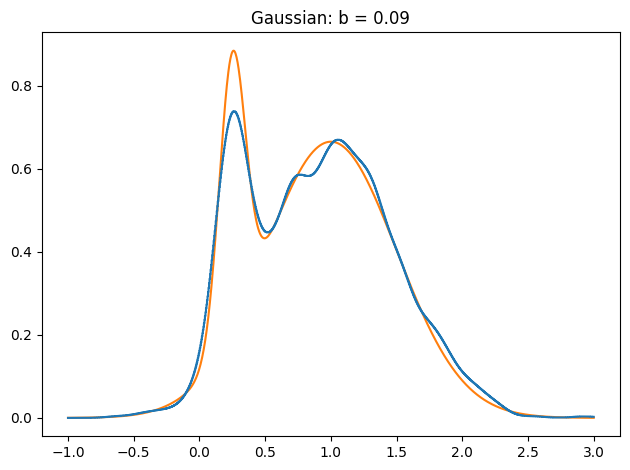

In [9]:
kde_gauss = KernelDensity(bandwidth=best_b, kernel='gaussian') 
kde_gauss.fit(x.reshape(-1, 1)) 
 
plt.plot(x_grid, np.exp(kde_gauss.score_samples(x_grid.reshape(-1, 1))), 
         marker='', drawstyle='steps-mid') 
plt.plot(x_grid, true_x_density(x_grid),  
         zorder=-10, marker='', color='tab:orange') 
plt.title('Gaussian: b = {0:.2f}'.format(best_b))
plt.tight_layout()

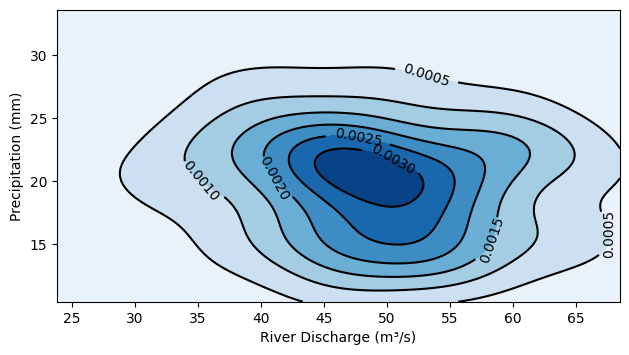

In [15]:
# Generating synthetic hydrological data 
np.random.seed(42) 
discharge = np.random.normal(loc=50, scale=10, size=100)  # Example discharge data (cubic meters per second) 
precipitation = np.random.normal(loc=20, scale=5, size=100)  # Example precipitation data (millimeters) 
 
# Combine discharge and precipitation into a 2D array 
hydro_data = np.column_stack((discharge, precipitation)) 
 
# Extract the two hydrological variables 
x = hydro_data[:, 0] 
y = hydro_data[:, 1] 
 
# Set the plot limits 
xmin, xmax = min(x), max(x) 
ymin, ymax = min(y), max(y)

import scipy.stats as stats

# Perform the kernel density estimate 
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j] 
positions = np.vstack([xx.ravel(), yy.ravel()]) 
values = np.vstack([x, y]) 
kernel = stats.gaussian_kde(values) 
f = np.reshape(kernel(positions).T, xx.shape) 
 
# print(kernel)

# Plotting 
fig, ax = plt.subplots() 
ax.set_xlim(xmin, xmax) 
ax.set_ylim(ymin, ymax) 
 
# Contourf plot 
cfset = ax.contourf(xx, yy, f, cmap='Blues') 
## Or kernel density estimate plot instead of the contourf plot 
ax.imshow(np.rot90(f), cmap='Blues', extent=[xmin, xmax, ymin, ymax]) 
 
# Contour plot 
cset = ax.contour(xx, yy, f, colors='k') 
 
# Label plot 
ax.clabel(cset, inline=1, fontsize=10) 
ax.set_xlabel('River Discharge (m³/s)') 
ax.set_ylabel('Precipitation (mm)') 
 
# Show the figure 
plt.tight_layout()

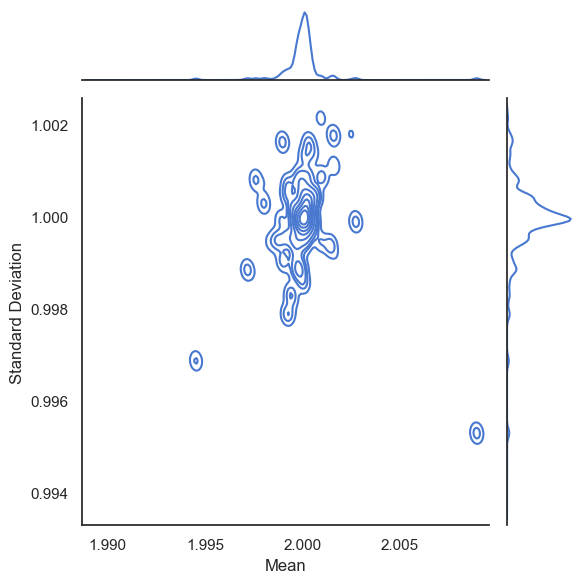

In [17]:
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import emcee  # You may need to install this package if not already installed 
 
# Generate synthetic data for demonstration purposes 
np.random.seed(42) 
data = np.random.normal(loc=3, scale=2, size=1000) 
 
# Define log likelihood function (assuming a normal distribution) 
def log_likelihood(theta, data): 
    mu, sigma = theta 
    model = np.random.normal(loc=mu, scale=sigma, size=len(data)) 
    return -0.5 * np.sum((model - data)**2) 
 
# Set up the MCMC sampler 
ndim = 2  # Number of parameters (mean and standard deviation) 
nwalkers = 100 
nsteps = 1000 
initial_guess = [2, 1]  # Initial guess for mean and standard deviation 
 
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_likelihood, 
args=[data]) 
 
# Run the MCMC sampler 
sampler.run_mcmc(initial_guess + 1e-4 * np.random.randn(nwalkers, ndim), 
nsteps) 
 
# Extract the samples from the MCMC chain 
samples = sampler.chain[:, 500:, :].reshape((-1, ndim)) 
 
# Plot the MCMC samples using KDE 
sns.set_theme(style="white", palette="muted") 
sns.jointplot(x=samples[:, 0], y=samples[:, 1], kind="kde", space=0, 
color="b") 
 
plt.xlabel("Mean") 
plt.ylabel("Standard Deviation") 
 
# Show the figure 
plt.tight_layout()

Estimated Mean: 3.0560549111415405 +/- 0.15206873536595722
Estimated Standard Deviation: 1.9573590613395608 +/- 0.06386693894194359


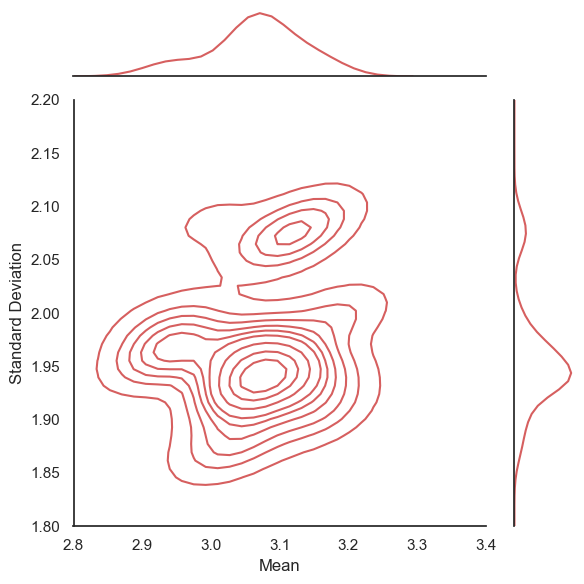

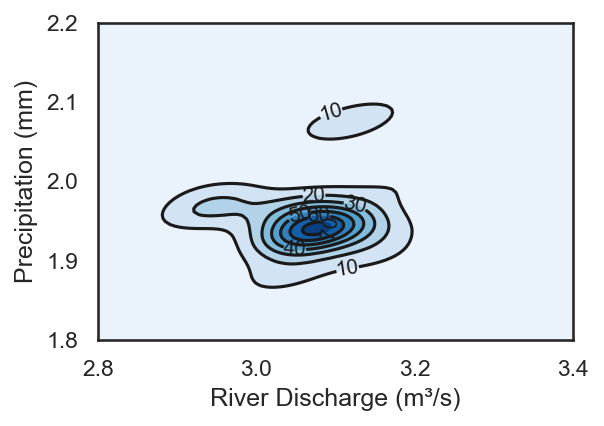

In [61]:
np.random.seed(42)

no_trials = 1000
x = np.linspace(0, no_trials, no_trials)
theta_vec = np.zeros((no_trials, 2))
data = np.random.normal(loc=3, scale=2, size=no_trials) 

def log_prior(theta): 
    mu, sigma = theta 
    if -10 < mu < 10 and 0 < sigma < 10: 
        return 0.0 
    return -np.inf

def log_likelihood(theta, data): 
    mu, sigma = theta 
    return -0.5 * len(data) * np.log(2 * np.pi * sigma**2) - np.sum((data - mu)**2) / (2 * sigma**2)

def log_posterior(theta, data): 
    return log_prior(theta) + log_likelihood(theta, data)


for i in range(no_trials):
    if i == 0:
        theta_vec[i, 0] = 0 # start with a mean of 0
        theta_vec[i, 1] = 1 # start with a std of 1

    else: 
        theta_vec[i,0] = stats.norm.rvs(loc = theta_vec[i-1, 0], scale = 0.5, size = 1)[0]
        theta_vec[i,1] = stats.norm.rvs(loc = theta_vec[i-1, 1], scale = 0.5, size = 1)[0]

        new = log_posterior(theta_vec[i], data)
        old = log_posterior(theta_vec[i-1], data)

        r_MH = new-old
        acceptance_alpha = np.min([1, r_MH])
        u_MH = np.log(np.random.uniform(0, 1))
        if u_MH < acceptance_alpha:
            # print('Accept')
            theta_vec[i] = theta_vec[i]
        else:
            # print('Reject')
            theta_vec[i] = theta_vec[i-1]
        # print(theta_vec[i], i)



# # Plot the MCMC samples using KDE 
sns.set_theme(style="white", palette="muted") 
sns.jointplot(x=theta_vec[:, 0], y=theta_vec[:, 1], kind="kde", space=0, 
color="r") 
plt.xlim(2.8, 3.4)
plt.ylim(1.8, 2.2)
 
plt.xlabel("Mean") 
plt.ylabel("Standard Deviation") 
 
# Show the figure 
plt.tight_layout()
 
# Extract the two hydrological variables 
x = theta_vec[:, 0] 
y = theta_vec[:, 1] 
 
# Set the plot limits 
xmin, xmax = 2.8, 3.4
ymin, ymax = 1.8, 2.2

print(f'Estimated Mean: {np.mean(theta_vec[:,0])} +/- {np.std(theta_vec[:,0])}')
print(f'Estimated Standard Deviation: {np.mean(theta_vec[:,1])} +/- {np.std(theta_vec[:,1])}')

fig, ax = plt.subplots(figsize=(6, 3), dpi = 150, tight_layout=True)

# Perform the kernel density estimate 
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j] 
positions = np.vstack([xx.ravel(), yy.ravel()]) 
values = np.vstack([x, y]) 
kernel = stats.gaussian_kde(values) 
f = np.reshape(kernel(positions).T, xx.shape) 

# # ax.set_xlim(2.5, 3.5) 
# ax.set_ylim(1.5, 2.5) 
 
# Contourf plot 
cfset = ax.contourf(xx, yy, f, cmap='Blues') 
## Or kernel density estimate plot instead of the contourf plot 
ax.imshow(np.rot90(f), cmap='Blues', extent=[xmin, xmax, ymin, ymax]) 
 
# Contour plot 
cset = ax.contour(xx, yy, f, colors='k') 
 
# Label plot 
ax.clabel(cset, inline=1, fontsize=10) 
ax.set_xlabel('River Discharge (m³/s)') 
ax.set_ylabel('Precipitation (mm)') 
 
# Show the figure 
plt.tight_layout()


In [18]:
#MCMC MH with multiple walkers

np.random.seed(2) # for reproducibility 
data = np.random.normal(loc=3, scale=2, size=1000) 

def monte_carlo(proposal_mean,proposal_std_dev,num_interations: int = 1):
 sample = np.random.normal(loc=proposal_mean,scale=proposal_std_dev,size=num_interations)
 return sample

def prior(theta): 
 mu, sigma = theta 
 if -5 < mu < 5 and 0 < sigma < 10:
   return np.log(1) # flat prior 

def log_likelihood(theta, data): 
    mu, sigma = theta 
    model = np.random.normal(loc=mu, scale=sigma, size=len(data)) 
    return -0.5 * np.sum((model - data)**2) 

def posterior(theta): 
 return prior(theta)+log_likelihood(theta) #Bayes' Theorem

def metropolis_hasting_outcome_flow(theta_new,theta_n1):
 #Calculate Posteriors
 post_new = posterior(theta_new)
 post_n1 = posterior(theta_n1)
 log_r = post_new-post_n1
 if log_r>1:
    return theta_new
 u = np.random.uniform(0,1)
 if np.log(u) < log_r:
    return theta_new
 else:
    return theta_n1

def monte_carlo_markov_chain_metropolis_hasting_flow(proposal_mean,proposal_std_dev,iterations):
 samples = np.zeros(iterations)
 samples[0] = proposal_mean
 for i in range(iterations-1):
  samples[i+1] = monte_carlo(samples[i],proposal_std_dev)
  samples[i+1] = metropolis_hasting_outcome_flow(samples[i+1],samples[i])
 return samples

iterations = 2000
n_walkers = 50
n_burn = 1000

guess = 2000*np.random.rand(n_walkers)

# initialize a 2D array to hold each walker's chain (n_walkers x iterations)
samples = np.zeros((n_walkers, iterations))
samples_out = np.zeros(n_walkers*(iterations-n_burn))
iteration_start = 0

for j in range(n_walkers):
 samples[j, :] = monte_carlo_markov_chain_metropolis_hasting_flow(guess[j], 30, iterations)
 iteration_end = (j+1)*(iterations-n_burn)
 samples_out[iteration_start:iteration_end] = samples[j,n_burn:]
 iteration_start = iteration_end

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4)) #

#Histogram of MC Output
ax1.hist(samples_out)
ax1.set_title('Histogram of MCMC & Metropolis Hastings')
ax1.set_ylabel('Count')
ax1.set_xlabel('Theta')

#Chart of MC Output per Iteration
ax2.plot(range(len(samples[0])),samples[0])
ax2.set_title('Evolution of Theta w/ One Walker')
ax2.set_ylabel('Theta')
ax2.set_xlabel('Iteration')



# plot a best-fit Gaussian 
F_fit = np.linspace(975, 1025) 
pdf = stats.norm(np.mean(samples_out), np.std(samples_out)).pdf(F_fit) 
ax3.plot(F_fit, pdf, '-k') 
ax3.set_xlabel("F"); ax2.set_ylabel("P(F)")

print(f"Mean of Theta: {np.mean(samples_out):.3f}")
print(f"Std of Theta: {np.std(samples_out):.3f}")

import emcee
import pandas as pd

np.random.seed(2) # for reproducibility
def log_prior(theta):
 return 1 # flat prior 

def log_likelihood(theta, F, e): 
 return -0.5 * np.sum(np.log(2 * np.pi * e ** 2) + (F - theta[0]) ** 2 / e ** 2) 

def log_posterior(theta, F, e): 
 return log_prior(theta) + log_likelihood(theta, F, e)

# ndim = 1 # number of parameters in the model 
# nwalkers = 50 # number of MCMC walkers 
# nburn = 1000 # "burn-in" period to let chains stabilize 
# nsteps = 2000 # number of MCMC steps to take 

 

# # we'll start at random locations between 0 and 2000

# starting_guesses = 2000 * np.random.rand(nwalkers, ndim) 

 

# import emcee 

# sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=[F, 

# e]) 

# sampler.run_mcmc(starting_guesses, nsteps) 

 

# sample = sampler.chain # shape = (nwalkers, nsteps, ndim) 

# sample = sampler.chain[:, nburn:, :].ravel() # discard burn-in points 

# print(len(sample))



# # plot a histogram of the sample 

# from scipy import stats 

# plt.hist(sample, bins=50, histtype="stepfilled", alpha=0.3) 

 

# # plot a best-fit Gaussian 

# F_fit = np.linspace(975, 1025) 

# pdf = stats.norm(np.mean(sample), np.std(sample)).pdf(F_fit) 

 

# plt.plot(F_fit, pdf, '-k') 

# plt.xlabel("F"); plt.ylabel("P(F)")



# data=pd.DataFrame()

# data["F"]=F_fit

# data["P(F)"]=pdf



# data.to_clipboard()



# print(""" 

#  F_true = {0} 

#  F_est = {1:.0f} +/- {2:.0f} (based on {3} measurements) 

#  """.format(1000, np.mean(sample), np.std(sample), 50)) 


ValueError: setting an array element with a sequence.